# Figure 4: Cross-Species Cross-Dataset Validation + Barrier Mechanism

**Panels:**
- **A** — Human single-cell: epithelial vs immune expression of AD risk genes
- **B** — Human Visium spatial (Oliveira 2025): APP pathway & myeloid modules
- **C** — Mouse Visium spatial d0 (Das 2022): APP pathway module
- **D** — Mouse d0 vs d14 comparison
- **E** — Mouse aging (Daly 2025): APP pathway gene expression across ages
- **F** — CD2AP x tight junction spatial co-expression

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.sparse import issparse
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 8, 'axes.titlesize': 10, 'axes.labelsize': 9,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

BASE = '../analysis/26_gsmap'
OUT = f'{BASE}/figures'
import os; os.makedirs(OUT, exist_ok=True)

# Gene lists — human
APP_GENES_H = ['APP', 'ADAM10', 'PICALM', 'CD2AP', 'SORL1', 'PSEN1']
MYELOID_GENES_H = ['TREM2', 'CD33', 'SPI1', 'INPP5D']
TJ_GENES_H = ['TJP1', 'OCLN', 'CLDN3', 'CLDN4', 'CLDN7', 'CDH1']
ALL_AD_H = APP_GENES_H + MYELOID_GENES_H

# Gene lists — mouse (capitalize first letter only)
APP_GENES_M = ['App', 'Adam10', 'Picalm', 'Cd2ap', 'Sorl1', 'Psen1']
MYELOID_GENES_M = ['Trem2', 'Cd33', 'Spi1', 'Inpp5d']

print("Setup complete.")

Setup complete.


Burclaff colon epithelial: 5254 cells
Smillie immune: 41650 cells


  APP: epi=70.6%, imm=8.4%


  ADAM10: epi=43.2%, imm=13.4%


  PICALM: epi=33.0%, imm=9.8%


  CD2AP: epi=49.2%, imm=9.6%


...

  PSEN1: epi=30.0%, imm=7.9%


  TREM2: epi=0.0%, imm=0.1%


  CD33: epi=0.4%, imm=1.3%


  SPI1: epi=24.3%, imm=10.6%


  INPP5D: epi=18.2%, imm=24.1%


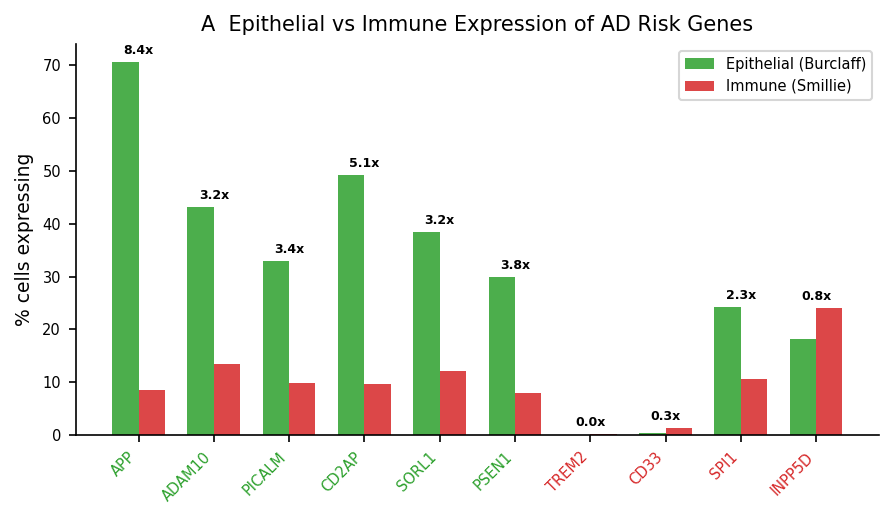

Panel A done.


In [2]:
# ── Panel A: Human single-cell epithelial vs immune expression ──

# Load Burclaff 2022 (epithelial) — genes are in var['feature_name']
burc = sc.read_h5ad(f'{BASE}/data/gut_atlas/Burclaff2022_colon_epi.h5ad', backed='r')
# Filter to colon tissues
colon_mask = burc.obs['tissue'].str.contains('colon', case=False, na=False)
colon_idx = burc.obs.index[colon_mask]
print(f"Burclaff colon epithelial: {len(colon_idx)} cells")

# Build feature_name -> var_name mapping
fname_map = dict(zip(burc.var['feature_name'], burc.var_names))

# Load Smillie 2019 (immune)
smil = sc.read_h5ad(f'{BASE}/data/gut_atlas/Smillie2019_colon.h5ad', backed='r')
smil_fname_map = dict(zip(smil.var['feature_name'], smil.var_names))
print(f"Smillie immune: {smil.n_obs} cells")

# For each gene: compute best epithelial %expr and best immune %expr
def pct_expr_backed(adata, var_id, cell_idx):
    """Compute % cells expressing a gene from backed adata."""
    if var_id not in adata.var_names:
        return 0.0
    col = list(adata.var_names).index(var_id)
    # Read the column for selected cells
    chunk = adata[cell_idx, col].X
    if issparse(chunk):
        chunk = chunk.toarray()
    chunk = np.asarray(chunk).flatten()
    return float(np.mean(chunk > 0) * 100)

results = []
for gene in ALL_AD_H:
    # Burclaff: map feature_name -> ensembl ID
    ens_burc = fname_map.get(gene, None)
    epi_pct = pct_expr_backed(burc, ens_burc, colon_idx) if ens_burc else 0.0
    
    # Smillie: map feature_name -> ensembl ID
    ens_smil = smil_fname_map.get(gene, None)
    imm_pct = pct_expr_backed(smil, ens_smil, smil.obs.index) if ens_smil else 0.0
    
    category = 'APP pathway' if gene in APP_GENES_H else 'Myeloid'
    results.append({'gene': gene, 'epithelial': epi_pct, 'immune': imm_pct, 'category': category})
    print(f"  {gene}: epi={epi_pct:.1f}%, imm={imm_pct:.1f}%")

df_expr = pd.DataFrame(results)

# Close backed files
burc.file.close()
smil.file.close()

# Plot grouped bar chart
fig_a, ax_a = plt.subplots(figsize=(6, 3.5))
x = np.arange(len(df_expr))
w = 0.35
bars_epi = ax_a.bar(x - w/2, df_expr['epithelial'], w, label='Epithelial (Burclaff)', color='#2ca02c', alpha=0.85)
bars_imm = ax_a.bar(x + w/2, df_expr['immune'], w, label='Immune (Smillie)', color='#d62728', alpha=0.85)

# Annotate ratios
for i, row in df_expr.iterrows():
    denom = max(row['immune'], 0.1)
    ratio = row['epithelial'] / denom
    top = max(row['epithelial'], row['immune'])
    ax_a.text(i, top + 1.5, f'{ratio:.1f}x', ha='center', fontsize=6, fontweight='bold')

ax_a.set_xticks(x)
ax_a.set_xticklabels(df_expr['gene'], rotation=45, ha='right')
ax_a.set_ylabel('% cells expressing')
ax_a.set_title('A  Epithelial vs Immune Expression of AD Risk Genes')
ax_a.legend(fontsize=7)

# Color x-tick labels by category
for i, row in df_expr.iterrows():
    color = '#2ca02c' if row['category'] == 'APP pathway' else '#d62728'
    ax_a.get_xticklabels()[i].set_color(color)

ax_a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print("Panel A done.")

Human Visium: 3887 spots in tissue


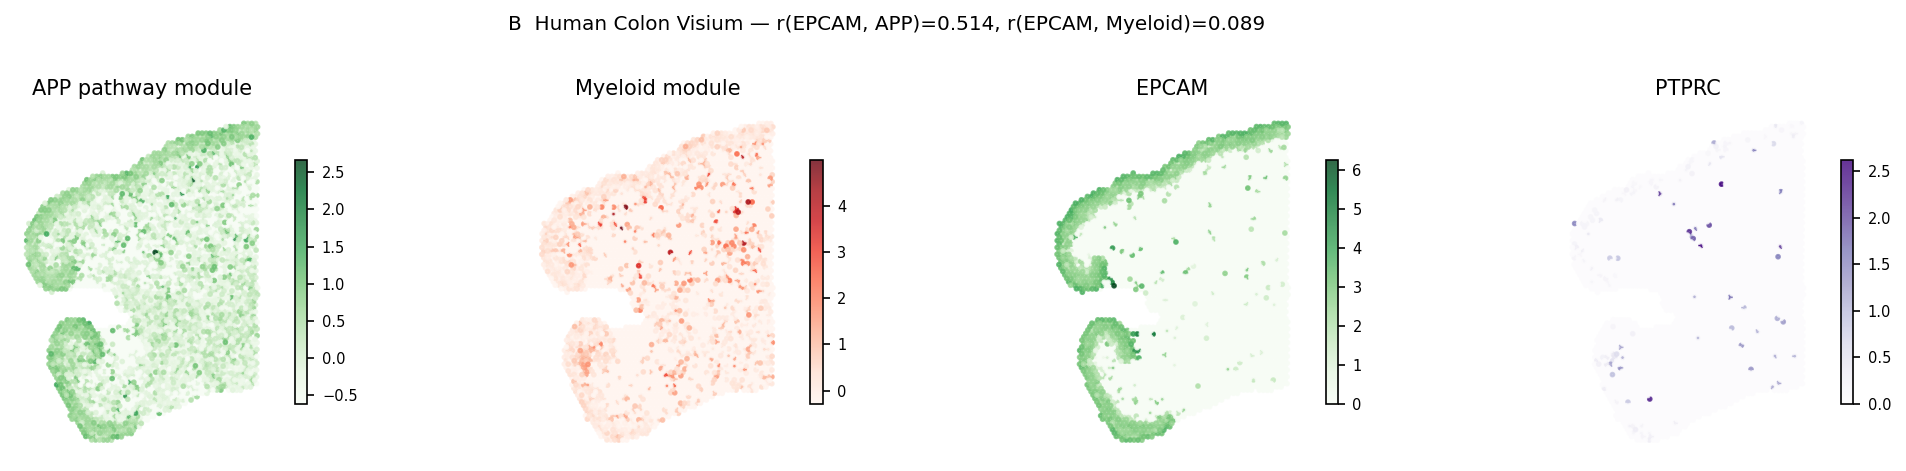

r(EPCAM, APP module) = 0.5141, p = 2.89e-261
r(EPCAM, Myeloid module) = 0.0894
r(PTPRC, Myeloid module) = 0.0409
Panel B done.


In [3]:
# ── Panel B: Human Visium spatial (Oliveira 2025) ──

# Load human colon Visium
adata_hv = sc.read_10x_h5(f'{BASE}/data/human_colon_visium/GSM8594562_P3NAT_filtered_feature_bc_matrix.h5')
adata_hv.var_names_make_unique()

# Add spatial coordinates
pos = pd.read_csv(f'{BASE}/data/human_colon_visium/GSM8594562_P3NAT_tissue_positions.csv', index_col=0)
adata_hv = adata_hv[adata_hv.obs.index.isin(pos.index)].copy()
pos = pos.loc[adata_hv.obs.index]
adata_hv.obsm['spatial'] = pos[['pxl_row_in_fullres', 'pxl_col_in_fullres']].values

# Filter to in_tissue spots
in_tissue = pos['in_tissue'] == 1
adata_hv = adata_hv[in_tissue.values].copy()
print(f"Human Visium: {adata_hv.n_obs} spots in tissue")

# Normalize
sc.pp.normalize_total(adata_hv, target_sum=1e4)
sc.pp.log1p(adata_hv)

def compute_module_score(adata, gene_list):
    """Mean z-scored expression of available genes."""
    avail = [g for g in gene_list if g in adata.var_names]
    if not avail:
        return np.zeros(adata.n_obs)
    mat = adata[:, avail].X
    if issparse(mat):
        mat = mat.toarray()
    mat = np.asarray(mat, dtype=float)
    # z-score per gene
    mu = mat.mean(axis=0)
    sd = mat.std(axis=0)
    sd[sd == 0] = 1
    z = (mat - mu) / sd
    return z.mean(axis=1)

adata_hv.obs['APP_module'] = compute_module_score(adata_hv, APP_GENES_H)
adata_hv.obs['Myeloid_module'] = compute_module_score(adata_hv, MYELOID_GENES_H)

# Get marker expressions
for g in ['EPCAM', 'PTPRC']:
    if g in adata_hv.var_names:
        col = adata_hv[:, g].X
        if issparse(col):
            col = col.toarray()
        adata_hv.obs[g] = np.asarray(col).flatten()

# 4 scatter subplots
fig_b, axes_b = plt.subplots(1, 4, figsize=(14, 3))
coords = adata_hv.obsm['spatial']

for ax, col, title, cmap in zip(
    axes_b,
    ['APP_module', 'Myeloid_module', 'EPCAM', 'PTPRC'],
    ['APP pathway module', 'Myeloid module', 'EPCAM', 'PTPRC'],
    ['Greens', 'Reds', 'Greens', 'Purples']
):
    vals = adata_hv.obs[col].values
    sc_plot = ax.scatter(coords[:, 1], coords[:, 0], c=vals, cmap=cmap, s=3, alpha=0.8, rasterized=True)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.colorbar(sc_plot, ax=ax, shrink=0.7)

# Report correlations
r_epcam_app, p_epcam_app = stats.pearsonr(adata_hv.obs['EPCAM'], adata_hv.obs['APP_module'])
r_epcam_mye, p_epcam_mye = stats.pearsonr(adata_hv.obs['EPCAM'], adata_hv.obs['Myeloid_module'])
r_ptprc_mye, p_ptprc_mye = stats.pearsonr(adata_hv.obs['PTPRC'], adata_hv.obs['Myeloid_module'])

fig_b.suptitle(f'B  Human Colon Visium — r(EPCAM, APP)={r_epcam_app:.3f}, r(EPCAM, Myeloid)={r_epcam_mye:.3f}', y=1.02)
plt.tight_layout()
plt.show()
print(f"r(EPCAM, APP module) = {r_epcam_app:.4f}, p = {p_epcam_app:.2e}")
print(f"r(EPCAM, Myeloid module) = {r_epcam_mye:.4f}")
print(f"r(PTPRC, Myeloid module) = {r_ptprc_mye:.4f}")
print("Panel B done.")

Mouse d0: 2604 spots


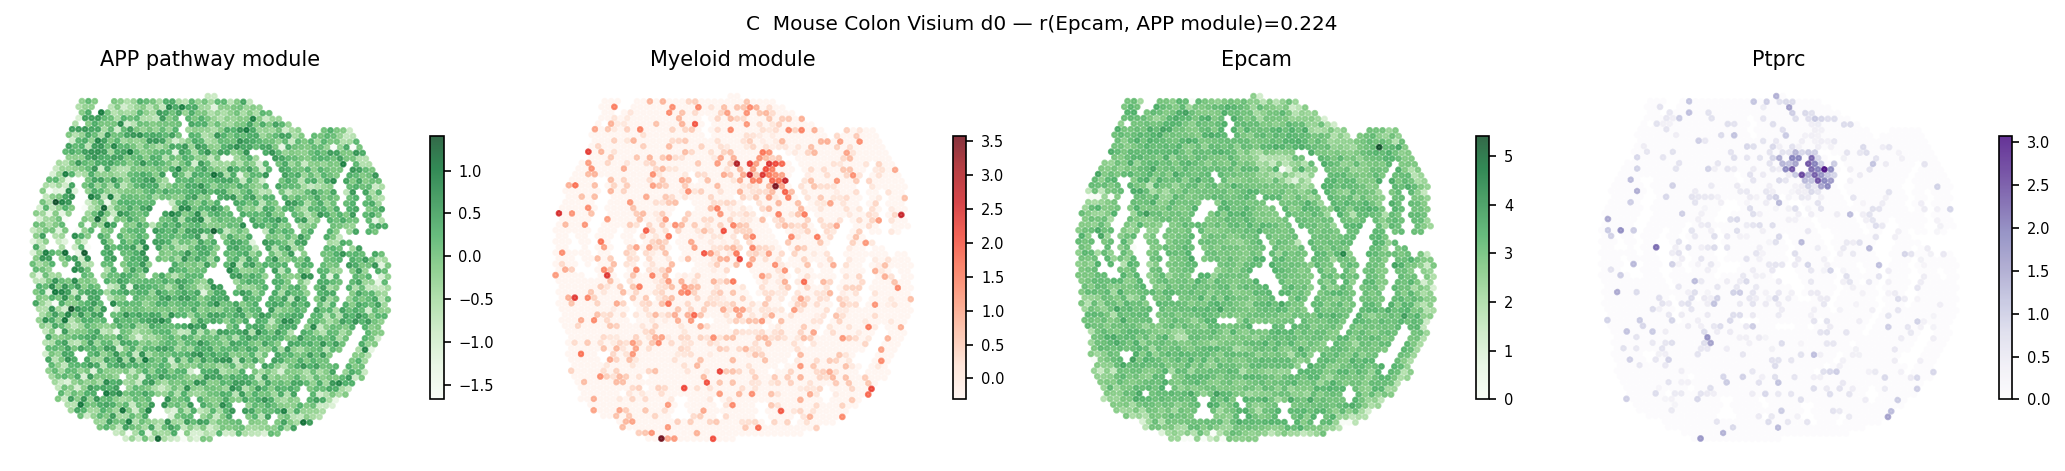

r(Epcam, APP module) d0 = 0.2238
Panel C done.


In [4]:
# ── Panel C: Mouse Visium spatial d0 (Das 2022) ──

def load_mouse_visium(h5_path, pos_path):
    """Load mouse Visium data with positions."""
    adata = sc.read_10x_h5(h5_path)
    adata.var_names_make_unique()
    
    # Load positions (no header for mouse format)
    pos = pd.read_csv(pos_path, header=None,
                       names=['barcode', 'in_tissue', 'array_row', 'array_col', 'pxl_row', 'pxl_col'])
    pos = pos.set_index('barcode')
    
    # Intersect
    common = adata.obs.index.intersection(pos.index)
    adata = adata[common].copy()
    pos = pos.loc[common]
    adata.obsm['spatial'] = pos[['pxl_row', 'pxl_col']].values
    
    # Filter to in_tissue
    mask = pos['in_tissue'] == 1
    adata = adata[mask.values].copy()
    
    # Normalize
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata

adata_d0 = load_mouse_visium(
    f'{BASE}/data/visium_colon/GSM5213483_V19S23-097_A1_S1_filtered_feature_bc_matrix.h5',
    f'{BASE}/data/visium_colon/GSM5213483_V19S23-097_A1_S1_tissue_positions_list.csv.gz'
)
print(f"Mouse d0: {adata_d0.n_obs} spots")

adata_d0.obs['APP_module'] = compute_module_score(adata_d0, APP_GENES_M)
adata_d0.obs['Myeloid_module'] = compute_module_score(adata_d0, MYELOID_GENES_M)

for g in ['Epcam', 'Ptprc']:
    if g in adata_d0.var_names:
        col = adata_d0[:, g].X
        if issparse(col):
            col = col.toarray()
        adata_d0.obs[g] = np.asarray(col).flatten()

# Spatial plots
fig_c, axes_c = plt.subplots(1, 4, figsize=(14, 3))
coords_d0 = adata_d0.obsm['spatial']

for ax, col, title, cmap in zip(
    axes_c,
    ['APP_module', 'Myeloid_module', 'Epcam', 'Ptprc'],
    ['APP pathway module', 'Myeloid module', 'Epcam', 'Ptprc'],
    ['Greens', 'Reds', 'Greens', 'Purples']
):
    vals = adata_d0.obs[col].values
    sc_plot = ax.scatter(coords_d0[:, 1], coords_d0[:, 0], c=vals, cmap=cmap, s=5, alpha=0.8, rasterized=True)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.colorbar(sc_plot, ax=ax, shrink=0.7)

r_epcam_app_d0, _ = stats.pearsonr(adata_d0.obs['Epcam'], adata_d0.obs['APP_module'])
fig_c.suptitle(f'C  Mouse Colon Visium d0 — r(Epcam, APP module)={r_epcam_app_d0:.3f}', y=1.02)
plt.tight_layout()
plt.show()
print(f"r(Epcam, APP module) d0 = {r_epcam_app_d0:.4f}")
print("Panel C done.")

Mouse d14: 3630 spots


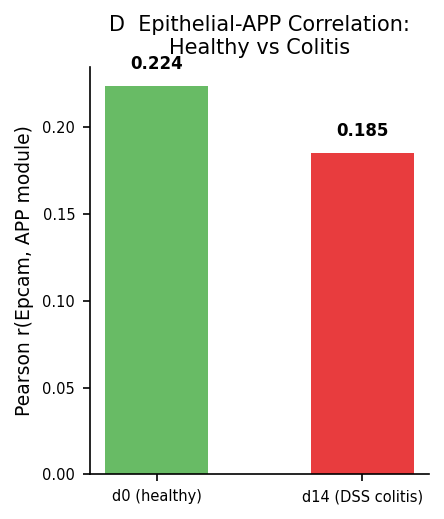

r(Epcam, APP) d0=0.2238, d14=0.1852
Panel D done.


In [5]:
# ── Panel D: Mouse d0 vs d14 comparison ──

adata_d14 = load_mouse_visium(
    f'{BASE}/data/visium_colon/GSM5213484_V19S23-097_B1_S2_filtered_feature_bc_matrix.h5',
    f'{BASE}/data/visium_colon/GSM5213484_V19S23-097_B1_S2_tissue_positions_list.csv.gz'
)
print(f"Mouse d14: {adata_d14.n_obs} spots")

adata_d14.obs['APP_module'] = compute_module_score(adata_d14, APP_GENES_M)

for g in ['Epcam']:
    if g in adata_d14.var_names:
        col = adata_d14[:, g].X
        if issparse(col):
            col = col.toarray()
        adata_d14.obs[g] = np.asarray(col).flatten()

r_d0, _ = stats.pearsonr(adata_d0.obs['Epcam'], adata_d0.obs['APP_module'])
r_d14, _ = stats.pearsonr(adata_d14.obs['Epcam'], adata_d14.obs['APP_module'])

fig_d, ax_d = plt.subplots(figsize=(3, 3.5))
bars = ax_d.bar(['d0 (healthy)', 'd14 (DSS colitis)'], [r_d0, r_d14],
                color=['#4daf4a', '#e41a1c'], alpha=0.85, width=0.5)
ax_d.set_ylabel("Pearson r(Epcam, APP module)")
ax_d.set_title('D  Epithelial-APP Correlation:\nHealthy vs Colitis')
ax_d.axhline(0, color='grey', lw=0.5)

for bar, val in zip(bars, [r_d0, r_d14]):
    ax_d.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax_d.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f"r(Epcam, APP) d0={r_d0:.4f}, d14={r_d14:.4f}")
print("Panel D done.")

Aging dataset: (352195, 21960)
Epithelial cells: 270550


  Age 0d: 2370 cells


  Age 1w: 1384 cells
  Age 2w: 714 cells


  Age 3w: 8331 cells


  Age 4w: 9187 cells


  Age 6w: 2085 cells


  Age 8w: 15219 cells


  Age 12w: 225989 cells


  Age 6m: 2403 cells


  Age 2yr: 2865 cells


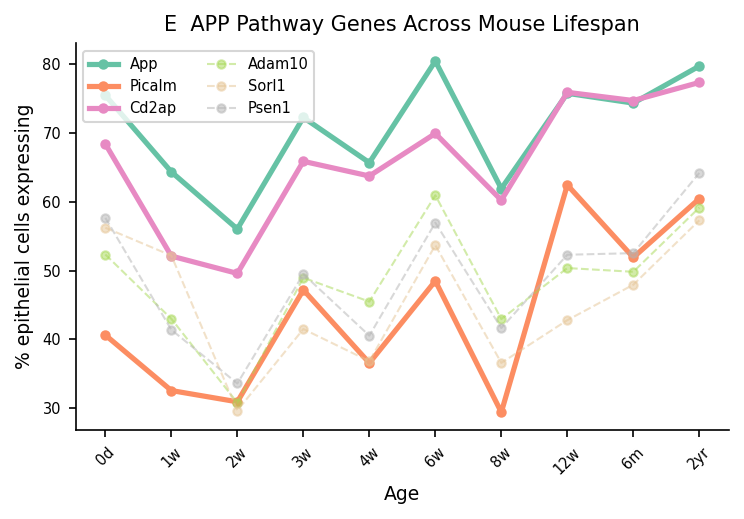

Panel E done.


In [6]:
# ── Panel E: Mouse aging (Daly 2025) ──

# Load with backed mode for the large file — we only need obs and specific gene columns
adata_age = sc.read_h5ad(f'{BASE}/data/age_colon/adata_larger_relabeling_after_tsne_stemfiltered_renamed.h5ad', backed='r')
print(f"Aging dataset: {adata_age.shape}")

# Filter to epithelial cell types
epi_types = ['TA', 'Colonocyte', 'Goblet', 'Tuft', 'Enteroendocrine', 'Stem', 'Cycling']
epi_mask = adata_age.obs['pheno_major_cell_types'].isin(epi_types)
epi_idx = adata_age.obs.index[epi_mask]
print(f"Epithelial cells: {len(epi_idx)}")

# Age ordering
age_order = ['0d', '1w', '2w', '3w', '4w', '6w', '8w', '12w', '6m', '2yr']
age_labels = adata_age.obs.loc[epi_idx, 'age']

# For each age x each APP gene: compute % expressing
key_genes = ['App', 'Picalm', 'Cd2ap', 'Adam10', 'Sorl1', 'Psen1']
gene_indices = {}
var_list = list(adata_age.var_names)
for g in key_genes:
    if g in var_list:
        gene_indices[g] = var_list.index(g)

age_pct = {g: [] for g in key_genes}
ages_present = []

for age in age_order:
    age_cells = epi_idx[age_labels == age]
    if len(age_cells) == 0:
        continue
    ages_present.append(age)
    for g in key_genes:
        if g in gene_indices:
            chunk = adata_age[age_cells, gene_indices[g]].X
            if issparse(chunk):
                chunk = chunk.toarray()
            pct = float(np.mean(np.asarray(chunk).flatten() > 0) * 100)
        else:
            pct = 0.0
        age_pct[g].append(pct)
    print(f"  Age {age}: {len(age_cells)} cells")

adata_age.file.close()

# Line plot
fig_e, ax_e = plt.subplots(figsize=(5, 3.5))
colors_e = plt.cm.Set2(np.linspace(0, 1, len(key_genes)))
highlight = ['App', 'Picalm', 'Cd2ap']

for g, color in zip(key_genes, colors_e):
    lw = 2.5 if g in highlight else 1.0
    ls = '-' if g in highlight else '--'
    alpha = 1.0 if g in highlight else 0.5
    ax_e.plot(ages_present, age_pct[g], '-o', label=g, color=color,
              linewidth=lw, linestyle=ls, alpha=alpha, markersize=4)

ax_e.set_xlabel('Age')
ax_e.set_ylabel('% epithelial cells expressing')
ax_e.set_title('E  APP Pathway Genes Across Mouse Lifespan')
ax_e.legend(fontsize=7, ncol=2)
ax_e.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Panel E done.")

Correlation matrix (AD barrier x TJ genes):
         TJP1   OCLN  CLDN3  CLDN4  CLDN7   CDH1
CD2AP   0.147  0.281  0.505  0.487  0.503  0.494
APP     0.060  0.059  0.055  0.036  0.045  0.048
PICALM  0.097  0.057  0.121  0.115  0.126  0.107
SORL1   0.117  0.253  0.458  0.446  0.458  0.426
ADAM10  0.028  0.046  0.077  0.059  0.070  0.056
PSEN1   0.097  0.154  0.269  0.257  0.265  0.242


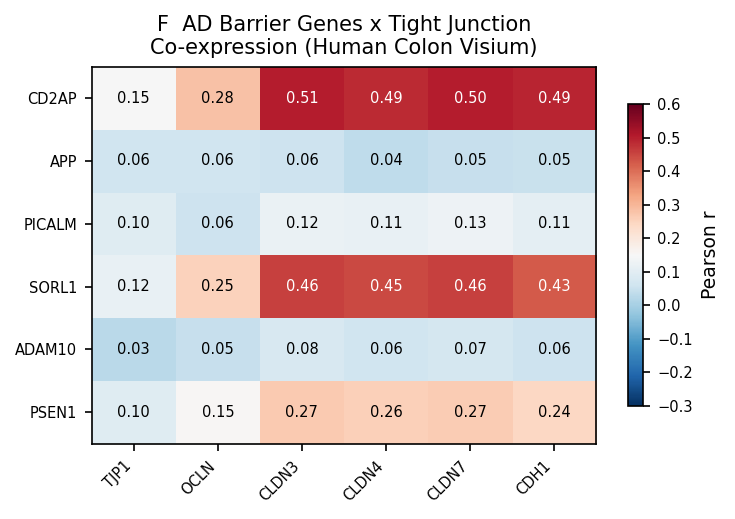

Panel F done.


In [7]:
# ── Panel F: CD2AP x tight junction spatial co-expression ──

# Use human Visium data (adata_hv already loaded and normalized)
# AD barrier genes (rows): APP pathway + CD2AP-related
ad_barrier = ['CD2AP', 'APP', 'PICALM', 'SORL1', 'ADAM10', 'PSEN1']
# Tight junction + endocytosis genes (cols)
tj_endo = ['TJP1', 'OCLN', 'CLDN3', 'CLDN4', 'CLDN7', 'CDH1']

# Compute correlation matrix
row_genes = [g for g in ad_barrier if g in adata_hv.var_names]
col_genes = [g for g in tj_endo if g in adata_hv.var_names]

corr_mat = np.zeros((len(row_genes), len(col_genes)))

for i, rg in enumerate(row_genes):
    r_expr = adata_hv[:, rg].X
    if issparse(r_expr):
        r_expr = r_expr.toarray()
    r_expr = np.asarray(r_expr).flatten()
    for j, cg in enumerate(col_genes):
        c_expr = adata_hv[:, cg].X
        if issparse(c_expr):
            c_expr = c_expr.toarray()
        c_expr = np.asarray(c_expr).flatten()
        r_val, _ = stats.pearsonr(r_expr, c_expr)
        corr_mat[i, j] = r_val

df_corr = pd.DataFrame(corr_mat, index=row_genes, columns=col_genes)
print("Correlation matrix (AD barrier x TJ genes):")
print(df_corr.round(3))

# Heatmap
fig_f, ax_f = plt.subplots(figsize=(5, 3.5))
im = ax_f.imshow(df_corr.values, cmap='RdBu_r', vmin=-0.3, vmax=0.6, aspect='auto')
ax_f.set_xticks(range(len(col_genes)))
ax_f.set_xticklabels(col_genes, rotation=45, ha='right')
ax_f.set_yticks(range(len(row_genes)))
ax_f.set_yticklabels(row_genes)

# Annotate values
for i in range(len(row_genes)):
    for j in range(len(col_genes)):
        val = df_corr.values[i, j]
        color = 'white' if abs(val) > 0.3 else 'black'
        ax_f.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax_f, shrink=0.8, label='Pearson r')
ax_f.set_title('F  AD Barrier Genes x Tight Junction\nCo-expression (Human Colon Visium)')
plt.tight_layout()
plt.show()
print("Panel F done.")

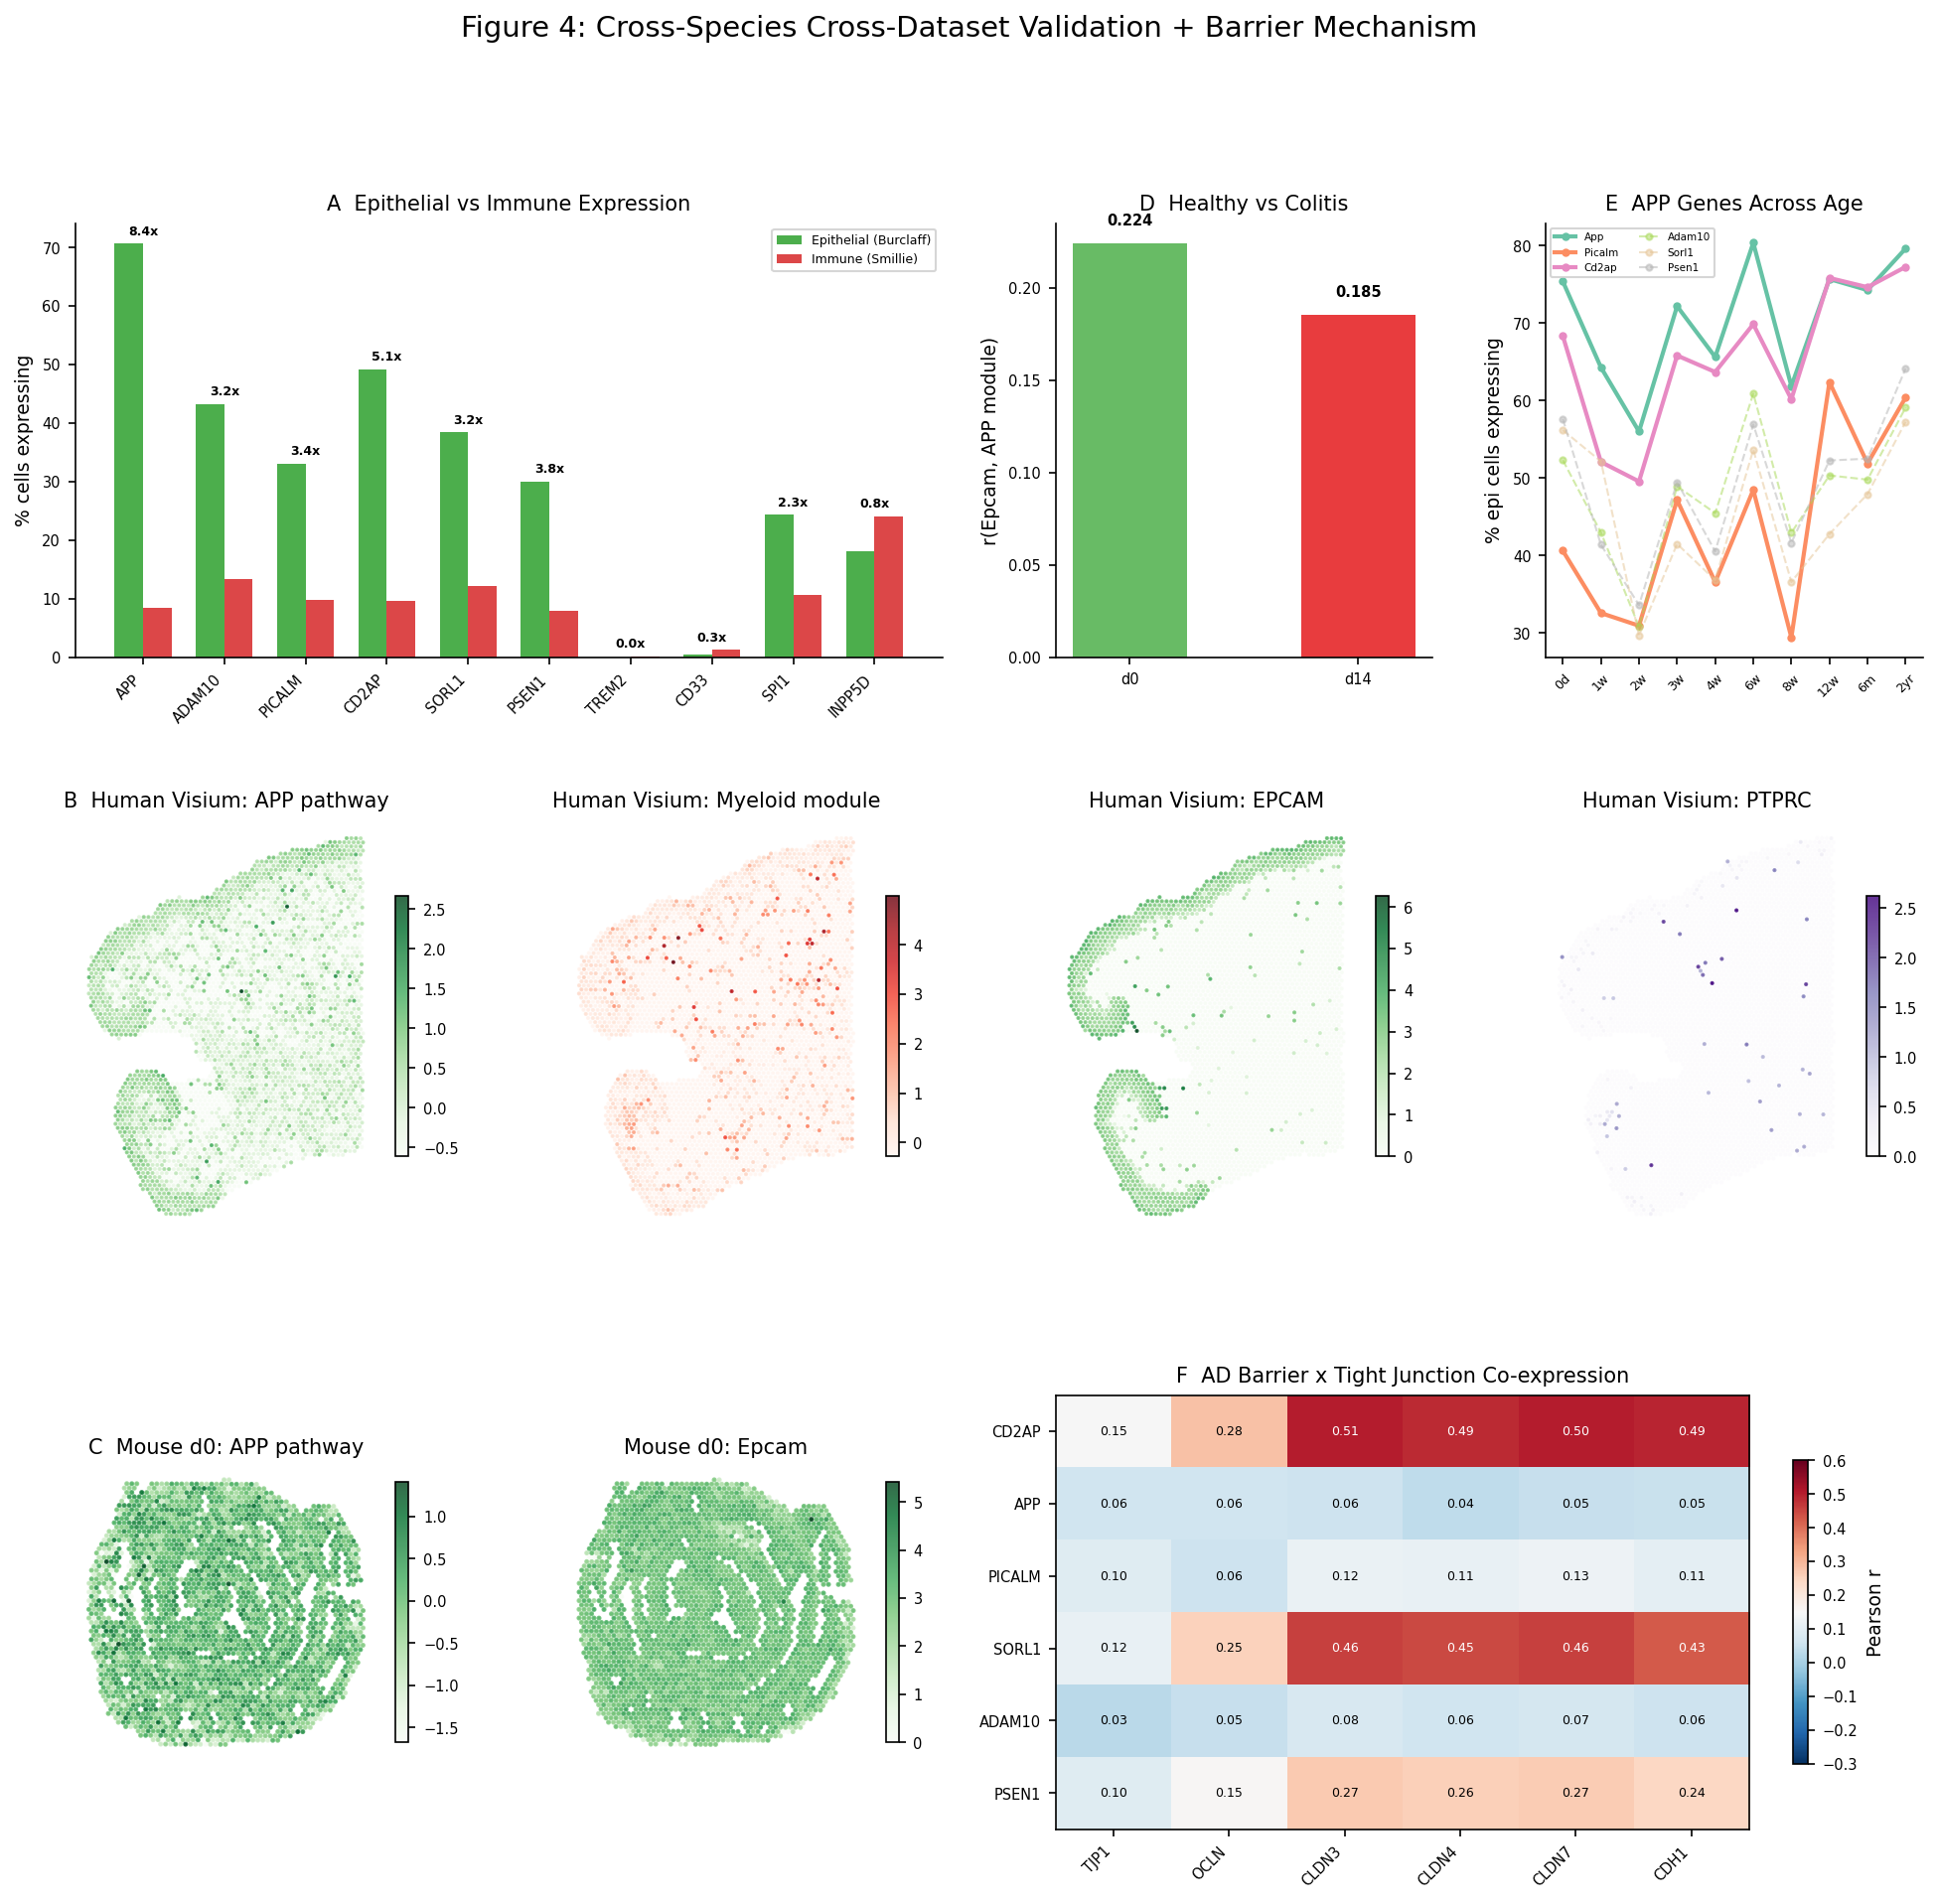

Saved to figures/Fig4_cross_validation.pdf and .png


In [8]:
# ── Cell 9: Composite figure + save ──

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)

# --- Panel A: Grouped bar chart (top-left, spans 2 cols) ---
ax_A = fig.add_subplot(gs[0, :2])
x = np.arange(len(df_expr))
w = 0.35
ax_A.bar(x - w/2, df_expr['epithelial'], w, label='Epithelial (Burclaff)', color='#2ca02c', alpha=0.85)
ax_A.bar(x + w/2, df_expr['immune'], w, label='Immune (Smillie)', color='#d62728', alpha=0.85)
for i, row in df_expr.iterrows():
    denom = max(row['immune'], 0.1)
    ratio = row['epithelial'] / denom
    top = max(row['epithelial'], row['immune'])
    ax_A.text(i, top + 1.5, f'{ratio:.1f}x', ha='center', fontsize=6, fontweight='bold')
ax_A.set_xticks(x)
ax_A.set_xticklabels(df_expr['gene'], rotation=45, ha='right')
ax_A.set_ylabel('% cells expressing')
ax_A.set_title('A  Epithelial vs Immune Expression')
ax_A.legend(fontsize=6)
ax_A.spines[['top', 'right']].set_visible(False)

# --- Panel D: d0 vs d14 bar (top-right) ---
ax_D = fig.add_subplot(gs[0, 2])
bars_D = ax_D.bar(['d0', 'd14'], [r_d0, r_d14], color=['#4daf4a', '#e41a1c'], alpha=0.85, width=0.5)
ax_D.set_ylabel("r(Epcam, APP module)")
ax_D.set_title('D  Healthy vs Colitis')
ax_D.axhline(0, color='grey', lw=0.5)
for bar, val in zip(bars_D, [r_d0, r_d14]):
    ax_D.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{val:.3f}', ha='center', fontsize=7, fontweight='bold')
ax_D.spines[['top', 'right']].set_visible(False)

# --- Panel E: Aging line plot (top-right) ---
ax_E = fig.add_subplot(gs[0, 3])
for g, color in zip(key_genes, colors_e):
    lw = 2.0 if g in highlight else 1.0
    ls = '-' if g in highlight else '--'
    alpha_val = 1.0 if g in highlight else 0.5
    ax_E.plot(range(len(ages_present)), age_pct[g], '-o', label=g, color=color,
              linewidth=lw, linestyle=ls, alpha=alpha_val, markersize=3)
ax_E.set_xticks(range(len(ages_present)))
ax_E.set_xticklabels(ages_present, rotation=45, fontsize=6)
ax_E.set_ylabel('% epi cells expressing')
ax_E.set_title('E  APP Genes Across Age')
ax_E.legend(fontsize=5, ncol=2)
ax_E.spines[['top', 'right']].set_visible(False)

# --- Panel B: Human Visium (middle row, all 4 cols) ---
for k, (col_name, title, cmap) in enumerate(zip(
    ['APP_module', 'Myeloid_module', 'EPCAM', 'PTPRC'],
    ['APP pathway', 'Myeloid module', 'EPCAM', 'PTPRC'],
    ['Greens', 'Reds', 'Greens', 'Purples']
)):
    ax_B = fig.add_subplot(gs[1, k])
    coords = adata_hv.obsm['spatial']
    vals = adata_hv.obs[col_name].values
    sc_p = ax_B.scatter(coords[:, 1], coords[:, 0], c=vals, cmap=cmap, s=1, alpha=0.8, rasterized=True)
    panel_label = 'B  ' if k == 0 else ''
    ax_B.set_title(f'{panel_label}Human Visium: {title}')
    ax_B.set_aspect('equal')
    ax_B.axis('off')
    plt.colorbar(sc_p, ax=ax_B, shrink=0.6)

# --- Panel C: Mouse Visium d0 (bottom-left, 2 cols as 2 subplots) ---
for k, (col_name, title, cmap) in enumerate(zip(
    ['APP_module', 'Epcam'],
    ['APP pathway', 'Epcam'],
    ['Greens', 'Greens']
)):
    ax_C = fig.add_subplot(gs[2, k])
    coords_d0 = adata_d0.obsm['spatial']
    vals = adata_d0.obs[col_name].values
    sc_p = ax_C.scatter(coords_d0[:, 1], coords_d0[:, 0], c=vals, cmap=cmap, s=2, alpha=0.8, rasterized=True)
    panel_label = 'C  ' if k == 0 else ''
    ax_C.set_title(f'{panel_label}Mouse d0: {title}')
    ax_C.set_aspect('equal')
    ax_C.axis('off')
    plt.colorbar(sc_p, ax=ax_C, shrink=0.6)

# --- Panel F: Heatmap (bottom-right, spans 2 cols) ---
ax_F = fig.add_subplot(gs[2, 2:])
im = ax_F.imshow(df_corr.values, cmap='RdBu_r', vmin=-0.3, vmax=0.6, aspect='auto')
ax_F.set_xticks(range(len(col_genes)))
ax_F.set_xticklabels(col_genes, rotation=45, ha='right')
ax_F.set_yticks(range(len(row_genes)))
ax_F.set_yticklabels(row_genes)
for i in range(len(row_genes)):
    for j in range(len(col_genes)):
        val = df_corr.values[i, j]
        color = 'white' if abs(val) > 0.3 else 'black'
        ax_F.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)
plt.colorbar(im, ax=ax_F, shrink=0.7, label='Pearson r')
ax_F.set_title('F  AD Barrier x Tight Junction Co-expression')

fig.suptitle('Figure 4: Cross-Species Cross-Dataset Validation + Barrier Mechanism', fontsize=14, y=0.98)

fig.savefig(f'{OUT}/Fig4_cross_validation.pdf', bbox_inches='tight')
fig.savefig(f'{OUT}/Fig4_cross_validation.png', bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved to {OUT}/Fig4_cross_validation.pdf and .png")